# Prepping Data Challenge - Week 04

**Unpopular Seats**

## Import Libraries

In [2]:
import numpy as np
import pandas as pd

In [39]:
import matplotlib.pyplot as plt

## Import Data

In [3]:
flow_card_data = pd.read_csv('D:01_Projekt_Portfolio/data_prepping_challenges/PD_2024_Wk_4_Input_Flow_Card.csv')
non_flow_card_data = pd.read_csv('D:01_Projekt_Portfolio/data_prepping_challenges/PD_2024_Wk_4_Input_Non_flow_Card.csv')
non_flow_card_data_2 = pd.read_csv('D:01_Projekt_Portfolio/data_prepping_challenges/PD_2024_Wk_4_Input_Non_flow_Card2.csv')

In [4]:
seats_data = pd.read_csv('D:01_Projekt_Portfolio/data_prepping_challenges/PD_2024_Wk_4_Input_Seat_Plan.csv')

## Challenges

### 1. Join the flow card and non-flow card data and create a `Flow Card?` variable to distinguish the two 

In [8]:
# Creating the Flow Card? column
flow_card_data['Flow Card?'] = True
non_flow_card_data['Flow Card?'] = False
non_flow_card_data_2['Flow Card?'] = False

In [9]:
occupied_seats_data = pd.concat([flow_card_data, non_flow_card_data, non_flow_card_data_2]).reset_index(drop=True)

### 2. Count bookings by seat, row, class, and Flow Card Status

In [30]:
bookings_by_seat = occupied_seats_data['Seat'].value_counts().sort_index()
bookings_by_row = occupied_seats_data['Row'].value_counts().sort_index()
bookings_by_class = occupied_seats_data['Class'].value_counts().sort_index()
bookings_by_flow_card_status = occupied_seats_data['Flow Card?'].value_counts().sort_index()

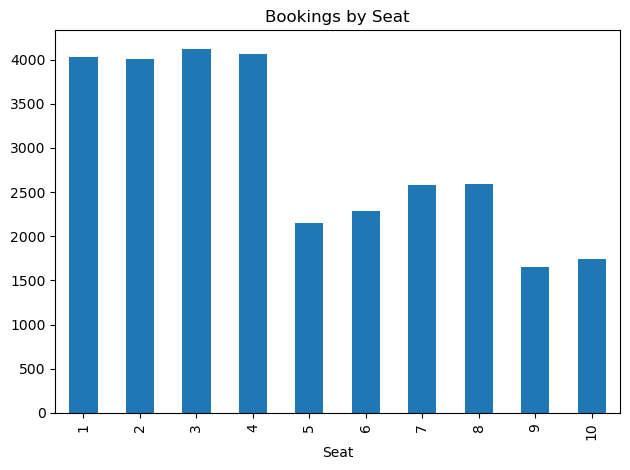

In [40]:
bookings_by_seat.plot(kind='bar')
plt.title('Bookings by Seat')
plt.tight_layout()
plt.show()

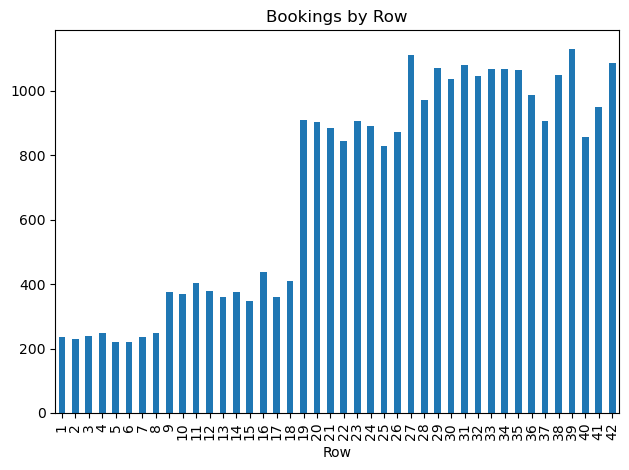

In [41]:
bookings_by_row.plot(kind='bar')
plt.title('Bookings by Row')
plt.tight_layout()
plt.show()

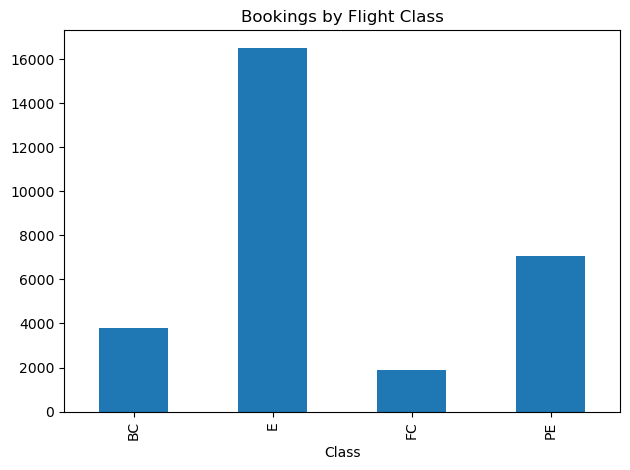

In [42]:
bookings_by_class.plot(kind='bar')
plt.title('Bookings by Flight Class')
plt.tight_layout()
plt.show()

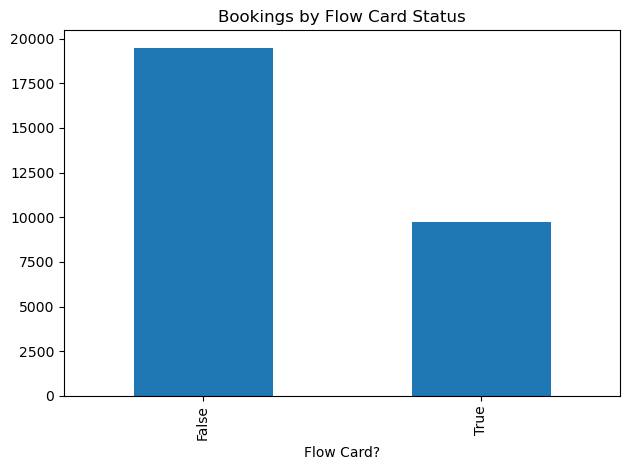

In [43]:
bookings_by_flow_card_status.plot(kind='bar')
plt.title('Bookings by Flow Card Status')
plt.tight_layout()
plt.show()

### 3. Join with the seats plane data and find the unoccupied seats

In [46]:
merged_seats = pd.merge(occupied_seats_data, seats_data, how='outer', on=['Class', 'Seat', 'Row'])

In [53]:
unoccupied_seats = merged_seats[merged_seats['CustomerID'].isna()][['Seat', 'Row', 'Class']]

## Save the results data

In [55]:
unoccupied_seats.to_csv('D:01_Projekt_Portfolio/data_prepping_challenges/04_unoccupied_seats.csv')